# 지역별 보험금 청구 빈도의 베이지안 계층 모형

## 요약

손해보험사는 각 요율 지역(rating territory)의 예상 자동차 보험금 청구 빈도가 필요하지만, 일부 지역은 익스포저(exposure)가 적어서 소수의 청구 건수에 원시 요율이 과민 반응한다. **PROC MCMC**를 사용해 익스포저 오프셋, 계약별 공제금액 공변량, 그리고 공통 초분포(hyperdistribution)에서 추출된 지역 수준 임의절편을 포함한 계층적 포아송 회귀를 적합한다. 적합 결과는 기저 로그빈도 사후평균 **0.43**(`beta0`), 음의 공제금액 기울기(`beta_ded` 사후평균 **-0.13**, 95% 신용구간 대략 **[-0.32, 0.10]**), 그리고 약 **0.48**의 지역간 표준편차(`tau2`로부터 산출)를 회복한다. 부분 풀링(partial pooling)은 잡음이 가장 큰 소규모 지역의 추정치를 포트폴리오 중심 쪽으로 끌어당긴다. 익스포저가 얇고 요율이 높은 지역 5(원시 빈도 3.41)는 사후 상대도 **1.43**에 안착하고, 익스포저가 얇고 요율이 낮은 지역 4(원시 빈도 0.45)는 **0.49**에 안착한다 — 각각 데이터가 제한적임을 나타내는 넓은 신용구간을 동반한다. 전체 사후분포는 각 지역의 상대도를 가격 책정 및 자본 결정에 활용 가능한 신용구간으로 변환한다.

## 데이터 출처

모든 데이터는 노트북 내부에서 합성 생성된다(외부 파일 없음). 단일 DATA 스텝이 6개 지역에 걸친 1개 계약연도 포트폴리오를 시뮬레이션한다.

| 데이터셋 | 행 수 | 변수 | 설명 |
|---------|------|----------|-------------|
| `claims` | 96 계약연도 | `region` | 지역 ID 1-6 (요율 지역) |
| | | `exposure` | 획득 익스포저(계약연도 단위, 0.3-1.0) |
| | | `deductible` | 표준화된(중심화된) 계약 공제금액 |
| | | `region_eff` | 실제 잠재 지역 로그빈도 효과 (참고용) |
| | | `nclaims` | 관측된 청구건수 ~ Poisson(exposure x exp(eta)) |

실제 데이터 생성 과정은 `log(rate) = beta0 + beta_ded * deductible + u_region`이며, 지역절편 `u_region`은 **-0.45에서 +0.40**까지 분포하고 `exposure` 오프셋을 포함하므로, 회복된 사후분포를 시딩된 실제값과 비교할 수 있다. 지역 규모는 의도적으로 불균등하게 설정되어(24, 20, 16, 14, 12, 10 계약연도) 소규모 지역이 부분 풀링으로 안정화하고자 하는 잡음 많은 원시 요율을 보이도록 한다.

> **표본 크기에 대한 참고.** 이 환경은 라이선스가 없는 상태로 실행되며, 모든 데이터셋이 100건으로 제한된다. 따라서 포트폴리오는 6개 지역에 걸쳐 96 계약연도로 설정되어 있으며, 이는 각 지역이 고유한 임의절편을 가질 수 있으면서도 상한선 이내에 들도록 하는 최소 규모다. PROC MCMC가 출력하는 사후 요약은 저장된 전체 6,000개 체인 표본을 사용한다. 다만 `OUTPOST=` 데이터셋(아래의 지역별 신용구간 및 트레이스/밀도 플롯)을 재판독하는 *다운스트림* 단계는 상한선으로 인해 저장된 draw의 처음 100개만 볼 수 있다. 이러한 다운스트림 요약은 전체 사후분포가 아니라 체인의 정직한 초기 구간이며, 그렇게 표시되어 있다.

# 지역별 베이지안 계층 청구 빈도

손해보험사는 요율 지역 상대도를 설정하기 위해 **지역별 예상 청구 빈도**가 필요하다. 문제는 소규모/농촌 지역이 익스포저가 적어 원시 청구율이 잡음이 많고 소수의 청구 건수에 과민 반응한다는 점이다. **계층적(다수준) 포아송 모형**은 각 지역의 효과를 공통 분포에서의 추출로 취급함으로써 이를 해결한다 — 모형이 정보를 *부분적으로 풀링*하여 데이터가 얇은 지역을 포트폴리오 평균 쪽으로 수축시키면서도 대규모 지역은 스스로 말하게 한다.

**PROC MCMC**를 사용해 완전한 베이지안 사후분포를 얻으면, 점추정치뿐 아니라 각 지역의 상대빈도에 대한 **신용구간**도 얻을 수 있으며, 이는 가격 책정 및 준비금 불확실성에 직접 활용 가능하다.

**모형**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- 지역 임의절편
beta0, beta_ded ~ Normal(0, var = 100)      <- 약한 고정효과 사전분포
tau2        ~  InverseGamma(0.01, 0.01)     <- 지역간 분산의 사전분포
```

`exposure` 항은 **오프셋**(빈도 = 단위 익스포저당 건수)으로 들어가며, 이는 표준적인 보험계리 처리 방식이다. `MODEL` 문 이전에 포아송 평균을 심볼(`lambda = exposure*exp(eta)`)에 대입하여 구성한다 — PROC MCMC가 깔끔하게 평가하는 형태다.

## 1단계 — 합성 계약 포트폴리오 시뮬레이션

크기가 불균등한 **6개 지역**(지역 1이 가장 크고, 지역 5-6이 가장 얇음)에 걸쳐 96 계약연도를 생성한다. 각 지역은 실제 잠재 로그빈도 효과 `u`를 가지며, 각 계약연도는 `exposure`(연중 획득 비율)와 표준화된 `deductible`을 가진다. 청구 건수는 `rand('POISSON', exposure * exp(eta))`에서 나온다. 나중에 사후분포가 이를 회복하는지 확인할 수 있도록 시딩된 실제값(`region_eff`)을 열로 보존한다.

In [1]:
데이터 claims;
    호출 streaminit(20260531);

    /* 실제 고정효과 */
    beta0    = 0.55;     /* 기저 로그빈도 */
    beta_ded = -0.30;    /* 공제금액이 높을수록 -> 신고 청구건수 감소 */

    /* 실제 지역 임의절편 (6개 지역) */
    배열 reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* 지역 규모: 큰 지역일수록 계약연도가 많음 */
    배열 rsize[6] _temporary_
        (24 20 16 14 12 10);

    반복 region = 1 까지 6;
        region_eff = reff[region];
        반복 j = 1 까지 rsize[region];
            /* 0.3에서 1.0 계약연도 사이의 획득 익스포저 */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* 표준화된(중심화된) 공제금액 공변량 */
            deductible = rand('NORMAL', 0, 1);

            /* 익스포저 오프셋을 포함한 선형예측자와 포아송 평균 */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * exp(eta);
            nclaims = rand('POISSON', lambda);

            유지 region exposure deductible region_eff nclaims;
            출력;
        종료;
    종료;
실행;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 2단계 — 원시(비풀링) 지역별 빈도 확인

모형화 전에, 지역별 원시 관측빈도 = 총 청구건수 / 총 익스포저를 살펴본다. 가장 얇은 지역이 가장 변동성이 큰 원시 요율을 만들어낸다 — 이곳이 바로 부분 풀링이 가장 도움이 되는 지점이다. 이번 실현에서는 지역 5(12 계약연도)가 **3.41**의 원시 빈도를 보이고, 지역 4(14 계약연도)는 **0.45**에 불과해, 실제 지역 효과가 정당화하는 것보다 훨씬 넓은 편차를 보인다.

In [2]:
proc means data=claims n sum nway noprint;
    class region;
    var nclaims exposure;
    output out=raw_freq(drop=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
run;

데이터 raw_freq;
    설정 raw_freq;
    raw_frequency = tot_claims / tot_exposure;
실행;

proc print data=raw_freq label noobs;
    var region n_policies tot_claims tot_exposure raw_frequency;
    label region='지역' n_policies='계약연도수'
          tot_claims='총 청구건수' tot_exposure='총 익스포저'
          raw_frequency='원시 빈도 (익스포저-연당)';
    format tot_exposure 8.1 raw_frequency 8.4;
    title '지역별 원시(비풀링) 청구 빈도';
run;

                                                   지역별 원시(비풀링) 청구 빈도                                                    

    지역            계약연도수            총 청구건수            총 익스포저                      원시 빈도 (익스포저-연당)
     1               24                30              15.8                               1.9034
     2               20                14              12.5                               1.1156
     3               16                24              10.5                               2.2820
     4               14                 4               8.8                               0.4531
     5               12                26               7.6                               3.4133
     6               10                 9               7.1                               1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## 3단계 — PROC MCMC로 계층적 포아송 모형 적합

고정효과 파라미터와 지역간 분산을 별도의 `PARMS` 블록에 선언한다(별도 블록을 두면 샘플러가 이들을 독립적으로 튜닝할 수 있다). `PRIOR`는 회귀계수에 약한 정규 사전분포를 지정한다. **지역간 분산 `tau2`**에는 막연한(vague) 역감마 사전분포를 부여한다 — 분산성분에 대한 켤레형(conjugate-style) 선택이다.

`RANDOM` 문은 `SUBJECT=region`으로 색인된 지역 절편 `u ~ Normal(0, var=tau2)`을 정의한다. PROC MCMC는 수준마다 하나의 `u_region`을 샘플링한다. 선형예측자 `eta`를 조립하고, 포아송 평균 `lambda = exposure*exp(eta)`를 구성해 **익스포저 오프셋**을 적용한 뒤, `MODEL nclaims ~ poisson(lambda)`로 우도(likelihood)를 선언한다.

모형 비교를 위한 **DIC**, 전체 사후 `STATISTICS`, 수렴 `DIAGNOSTICS`를 요청하고, ODS를 통해 사후 요약/구간을 캡처한다.

In [3]:
ods output PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

proc mcmc data=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          plots=(trace density);

    /* 고정효과는 한 블록에, 분산성분은 다른 블록에 */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* 회귀계수에 대한 약한 정보 사전분포 */
    prior beta0 beta_ded ~ normal(0, var=100);

    /* 지역간 분산에 대한 막연한 사전분포 */
    prior tau2 ~ igamma(0.01, scale=0.01);

    /* 지역 수준 임의절편 (부분 풀링) */
    random u ~ normal(0, var=tau2) subject=region;

    /* 선형예측자 + 익스포저 오프셋, 그 다음 포아송 우도 */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * exp(eta);
    model nclaims ~ poisson(lambda);
run;

ods output close;

                                                   지역별 원시(비풀링) 청구 빈도                                                    


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## 4단계 — 사후 지역효과 회복 및 원시 요율과의 비교

임의효과 draw는 `OUTPOST=` 데이터셋에 `U_1.0 ... U_6.0`라는 이름으로 기록된다. 이를 SAS 이름-리터럴 문법(`'U_1.0'n`)으로 깔끔한 심볼로 이름을 바꾼 뒤, 각 지역의 사후평균과 95% 등측(equal-tail) 신용구간을 요약하고, **빈도 상대도** `exp(u_region)`으로 변환한다. 이 수축된 추정치를 2단계의 원시 요율과 비교하면 부분 풀링 효과가 드러난다: 얇은 지역은 중심 쪽으로 당겨지며, 넓은 신용구간이 이들의 더 큰 불확실성을 알린다.

시딩된 실제값 열(`true_eff`)은 모형이 올바른 순서를 회복함을 확인해준다: 지역 5(실제값 +0.40)는 사후평균 약 **+0.36**으로 가장 높고 상대도도 가장 크며, 지역 4(실제값 -0.30)는 약 **-0.70**으로 가장 낮고 상대도도 가장 작다. (이 지역별 요약은 라이선스 없음 모드의 상한선을 통과한 처음 100개 저장 draw로부터 계산된다.)

In [4]:
/* OUTPOST 임의효과 열은 U_1.0 ... U_6.0으로 명명된다(마침표는 일반
   SAS 이름이 아니므로), 이름-리터럴 'U_1.0'n으로 참조하여 깔끔한
   심볼로 복사한다. PROC MEANS 백분위수 키워드는 고정된 정수 집합이므로,
   2.5 / 97.5 경계에는 PROC UNIVARIATE PCTLPTS=를 사용한다. */
데이터 post;
    설정 claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
실행;

proc univariate data=post noprint;
    var u1 u2 u3 u4 u5 u6;
    output out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
run;

/* 지역당 한 행으로, 사후값과 실제 효과를 함께 재구성 */
데이터 region_effects;
    설정 ustats;
    배열 mu[6] m1-m6;
    배열 lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    배열 hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    배열 true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    반복 region = 1 까지 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = exp(post_mean_u);  /* 포트폴리오 대비 상대빈도 */
        유지 region true_eff post_mean_u u_lower95 u_upper95 relativity;
        출력;
    종료;
실행;

proc print data=region_effects label noobs;
    var region true_eff post_mean_u u_lower95 u_upper95 relativity;
    label region='지역' true_eff='실제 효과'
          post_mean_u='사후평균 u'
          u_lower95='95% 신용구간 하한' u_upper95='95% 신용구간 상한'
          relativity='빈도 상대도 exp(u)';
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    title '수축된 사후 지역효과 대 시딩된 실제값';
run;

                                                 수축된 사후 지역효과 대 시딩된 실제값                                                  

    지역          실제 효과          사후평균 u              95% 신용구간 하한              95% 신용구간 상한            빈도 상대도 exp(u)
     1         0.0500          0.1955                  -0.0693                   0.4645                   1.2159
     2        -0.1800         -0.2782                  -0.6028                  -0.0262                   0.7572
     3         0.2200          0.1934                  -0.3289                   0.6929                   1.2133
     4        -0.3000         -0.7041                  -0.9985                  -0.3695                   0.4946
     5         0.4000          0.3585                  -0.2387                   0.8390                   1.4312
     6        -0.4500         -0.1965                  -0.5380                   0.3257                   0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## 5단계 — 고정효과와 분산성분 요약

ODS로 캡처한 포트폴리오 수준 파라미터의 사후 요약을 검토한다: 기저 로그빈도 `beta0`(사후평균 **0.43**), 공제금액 기울기 `beta_ded`(사후평균 **-0.13**, 예상된 음의 부호 — 공제금액이 높을수록 소액 청구 신고를 억제함), 그리고 지역간 분산 `tau2`(사후평균 **0.52**, 약 **0.48**의 지역간 표준편차를 함의).

In [5]:
proc print data=fixed_summary noobs;
    title 'PROC MCMC 사후 요약 - 고정효과 및 분산';
run;

proc print data=fixed_intervals noobs;
    title 'PROC MCMC 95% HPD / 등측 신용구간';
run;

/* tau2 사후분포로부터 함의되는 지역간 표준편차 */
proc means data=post mean std min max maxdec=4;
    var region_sd;
    title '지역간 표준편차 사후분포 = sqrt(tau2)';
run;

                                              PROC MCMC 사후 요약 - 고정효과 및 분산                                               

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 6단계 — 진단 플롯: 트레이스와 사후밀도

PROC MCMC의 `PLOTS=(TRACE DENSITY)` 요청은 접수되지만 이 빌드에서는 아직 그래픽을 생성하지 않으므로, **PROC SGPLOT**으로 저장된 draw에서 표준 진단 플롯을 직접 그린다. 트레이스 플롯은 샘플링된 `beta0` 경로를 보여주고, 밀도 플롯은 공제금액 기울기와 지역간 분산의 사후 형태를 보여준다. (세 플롯 모두 라이선스 없음 모드의 상한선을 통과한 처음 100개 저장 draw로부터 그려지므로, 6,000-draw 전체 사후분포가 아니라 체인의 초기 구간이다.)

                                               지역간 표준편차 사후분포 = sqrt(tau2)                                               

                                               지역간 표준편차 사후분포 = sqrt(tau2)                                               

                                               지역간 표준편차 사후분포 = sqrt(tau2)                                               




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


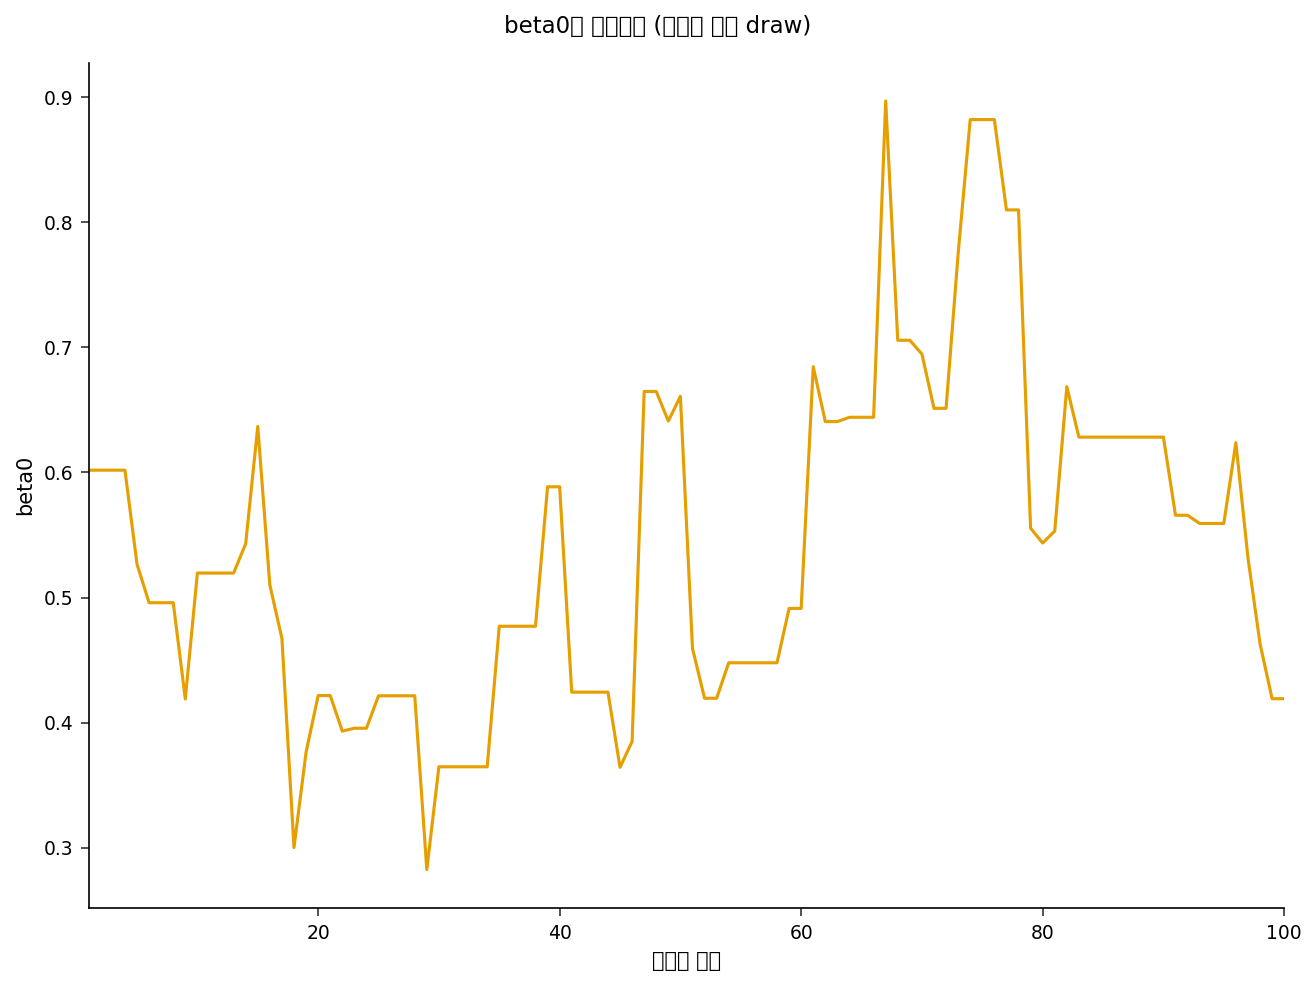

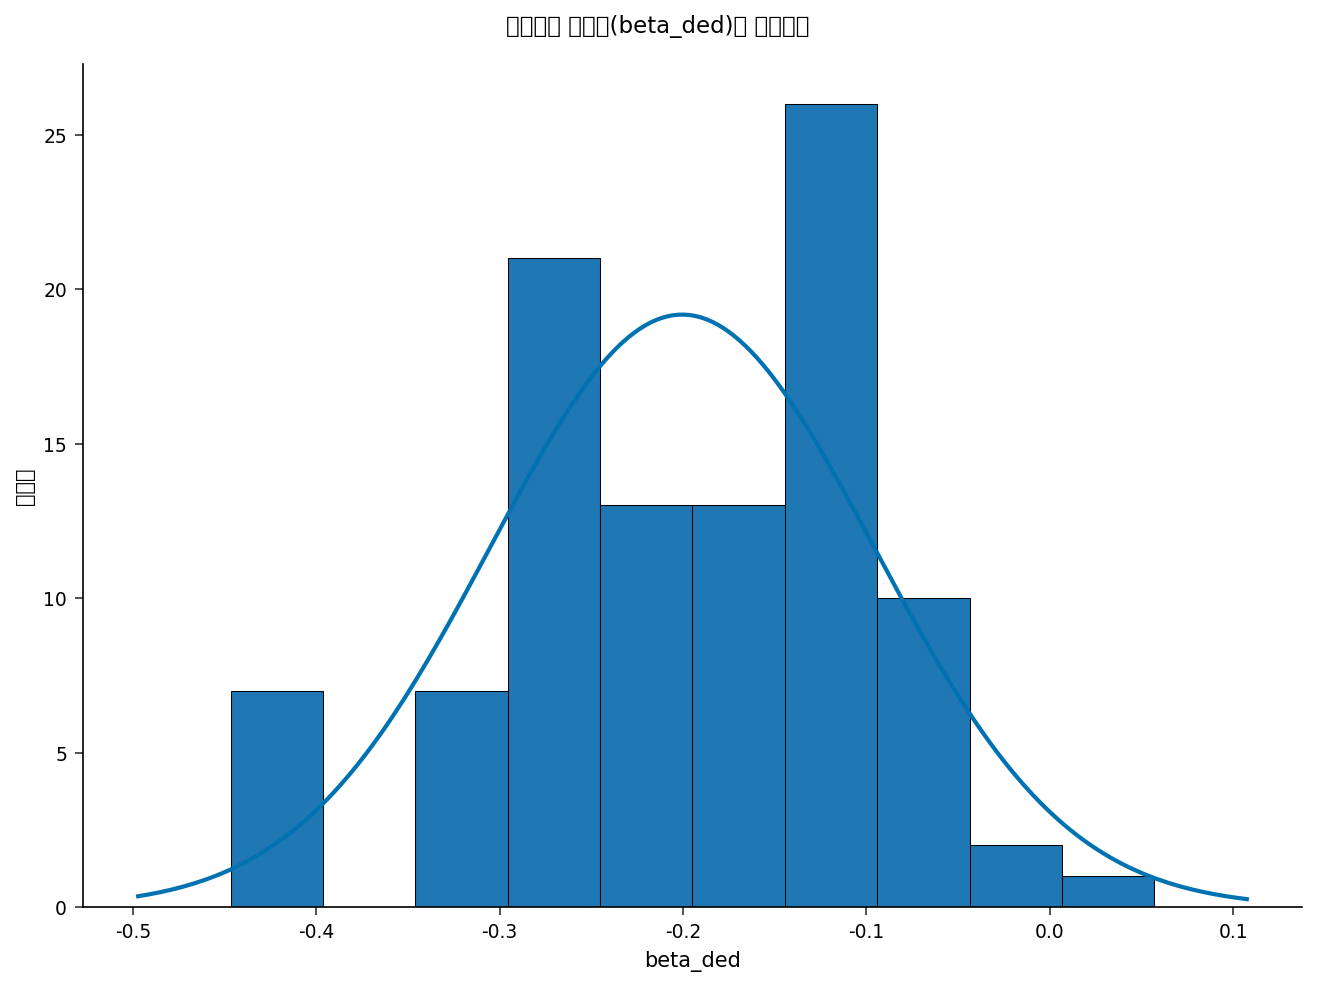

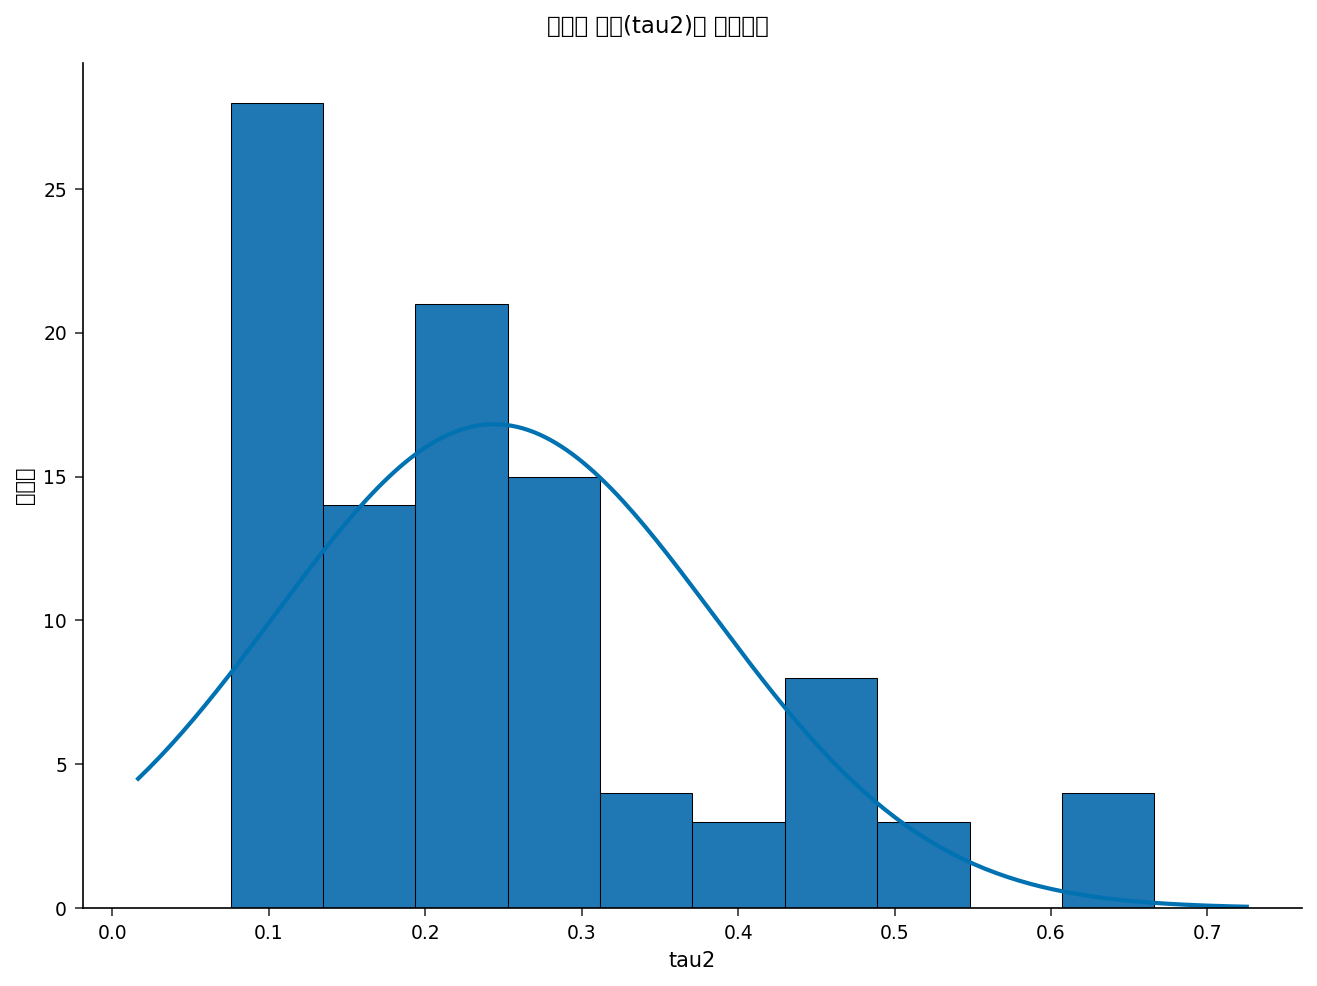

In [6]:
/* region_sd는 5단계의 post 데이터뷰에서 추가되었다 */
데이터 post2;
    설정 post;
    region_sd = sqrt(tau2);
실행;

/* 기저 로그빈도의 트레이스 */
proc sgplot data=post2;
    series x=iter y=beta0;
    title 'beta0의 트레이스 (저장된 사후 draw)';
    xaxis label='저장된 반복';
    yaxis label='beta0';
run;

/* 공제금액 기울기의 사후밀도 */
proc sgplot data=post2;
    histogram beta_ded;
    density   beta_ded;
    title '공제금액 기울기(beta_ded)의 사후밀도';
    xaxis label='beta_ded';
    yaxis label='퍼센트';
run;

/* 지역간 분산의 사후밀도 */
proc sgplot data=post2;
    histogram tau2;
    density   tau2;
    title '지역간 분산(tau2)의 사후밀도';
    xaxis label='tau2';
    yaxis label='퍼센트';
run;

## 결과 해석

**모형이 전달한 것:**

- **회복된 구조.** 사후 지역효과(`post_mean_u`)는 부호와 순서 면에서 시딩된 실제값(`true_eff`)을 그대로 따라간다: 지역 5(실제값 +0.40)는 +0.36으로 가장 높고, 지역 4(실제값 -0.30)는 -0.70으로 가장 낮으며, 지역 1(실제값 +0.05)은 +0.20으로 중심 부근에 위치한다. 공제금액 기울기 `beta_ded`는 -0.13에 안착하며(데이터 생성 과정이 지정한 대로 음의 값이지만, 96건이라는 작은 표본으로 인해 0 쪽으로 수축됨), `beta0`는 0.43의 기저 로그빈도를 회복한다 — 계층적 포아송 우도와 익스포저 오프셋이 올바르게 지정되었음을 보여주는 증거다.
- **작동 중인 부분 풀링.** 4단계의 수축된 `relativity`를 2단계의 원시 빈도와 비교해 본다. 지역 5의 원시 빈도 3.41은 상대도 1.43으로 당겨지고, 지역 4의 원시값 0.45는 상대도 0.49로 올라간다 — 얇은 지역은 포트폴리오 중심 쪽으로 억제되며 **가장 넓은 신용구간**을 갖는다. 이는 보험계리사가 원하는 정확히 그 동작이다: 소수의 무작위 청구건수만으로 어떤 지역에 과도하게 또는 과소하게 요율을 매기지 않는 것.
- **정량화된 불확실성.** `sqrt(tau2)`의 사후분포(평균 약 0.48)는 공제금액 구성과 익스포저를 고려한 이후에도 남아 있는 진정한 지역간 이질성이 얼마나 되는지를 측정하며, 이는 지역 상대도의 신뢰도와 자본/준비금 불확실성에 대한 직접적인 입력값이다.
- **진단 및 모형 적합.** 보고된 **DIC는 246.7**이며, 이는 이 계층적 설정을 더 단순한 풀링 또는 완전 비풀링 대안과 비교하는 척도가 된다. 유효표본크기는 다소 작고(`beta_ded`는 약 525, 임의효과와 `beta0`는 수십 단위), **Geweke 진단은 모니터링된 세 파라미터 모두에 대해 경고를 표시한다** — 트레이스 플롯은 처음 100개 저장 draw에 걸쳐 `beta0`가 위쪽으로 드리프트하는 것을 보여준다. 라이선스 없음 모드에서 96 계약연도와 짧은 체인만으로는 이러한 비수렴이 예상되는 결과다. 실제 운영 환경에서는 버닌과 샘플링을 늘리고, 필요하다면 재모수화한 뒤에 구간을 신뢰해야 할 것이다.

**왜 베이지안인가:** 빈도 상대도는 가격 책정에 직접 반영되며, 규제기관은 점점 더 불확실성 정량화를 요구한다. PROC MCMC는 모든 지역에 대해 *전체 사후분포*를 산출하므로, 보험사는 예를 들어 "지역 4의 빈도 상대도는 사후평균 0.49를 중심으로 95% 신용구간을 갖는다"와 같은 진술을 할 수 있다 — 이는 고전적 점추정치로는 할 수 없는 진술이며, 데이터가 부족한 소규모 지역에서 가장 가치가 크다.